In [1]:
import re
import datetime
import pathlib
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
VERSION = datetime.datetime.now().strftime("%y%m%d")
print(f"Execute Date: {VERSION}")

Execute Date: 260322


## Parameters for papermill

In [3]:
foldseek_result_tsv = pathlib.Path("../test/oryza_sativa_test_100genes_202603/foldseek_output_human_proteome_v6_os_100_genes_9606.tsv")
query_uniprot_idmapping_tsv = pathlib.Path("../test/oryza_sativa_test_100genes_202603/os_100_genes_idmapping_all.tsv")
water_result_dir_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/result_water")
needle_result_dir_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/result_needle")
query_gene_list_tsv_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/oryza_sativa_random_100genes_list.tsv")
togoid_convert_tsv_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/foldseek_target_species_togoid_convert.tsv")

In [4]:
# Parameters
foldseek_result_tsv = "/tmp/fwq4h5wo/stg53a657b5-6e5c-4e19-a8d7-b300148ec2da/foldseek_os_random_9606.tsv"
query_uniprot_idmapping_tsv = "/tmp/fwq4h5wo/stg80d9d441-f095-4593-b5e5-b16996fdb49c/os_100_genes_idmapping_all.tsv"
water_result_dir_path = "/tmp/fwq4h5wo/stg81e81d33-b4ca-4e47-8016-7f44a3b83c34/result_water"
needle_result_dir_path = "/tmp/fwq4h5wo/stg44f16d31-d7f5-4ed0-85a2-241ea4ee3c87/result_needle"
query_gene_list_tsv_path = "/tmp/fwq4h5wo/stg225c7f26-5996-41d8-85d3-eb818f66435f/oryza_sativa_random_100genes_list.tsv"
togoid_convert_tsv_path = "/tmp/fwq4h5wo/stg516057ab-61ff-4ac5-836d-342d173619da/foldseek_hit_species_togoid_convert.tsv"


&nbsp;

&nbsp;

&nbsp;

## (1) Foldseek (Structural Alignment) Result

- Foldseek version: [10-941cd33](https://github.com/steineggerlab/foldseek/releases/tag/10-941cd33)
- About Column name: [foldseek GitHub page](https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search)
- In this workflow, foldseek alignment type is `TM-align` (default). So, `e-value` column means `(qTMscore+tTMscore) / 2`
- More details: [TM-align Alignment mode](https://github.com/steineggerlab/foldseek?tab=readme-ov-file#alignment-mode)

&nbsp;

### About Hit Pairs

- In this analysis workflow, the results are output with multiple hits remaining for a single query UniProt ID (protein structure).

&nbsp;

In [5]:
foldseek_result_df = pl.read_csv(
    foldseek_result_tsv,
    separator='\t'
).with_columns(
    (pl.col("UniProt Accession").str.extract(r"AF-(.*?)-F1", 1).alias("UniProt Accession")), # "?" means non-greedy
    (pl.col("foldseek hit").str.extract(r"AF-(.*?)-F1", 1).alias("foldseek hit"))
)

foldseek_result = pl.read_csv(
    query_uniprot_idmapping_tsv, # query idmapping
    separator='\t'
).join(
    foldseek_result_df,
    on="UniProt Accession",
    how="inner",
    coalesce=True
)

display(foldseek_result)

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,qaln,taln,mismatch,lddtfull
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,str,i64,str
"""Os12g0159100""","""A0A0P0Y788""","""O60880""",0.3151,0.116,6,6.1,0.061,5,21,81,100,26,106,128,81,0.61,0.633,0.4378,0.3853,0.3213,0.5385,4.025,"""NCFHFVAVHG-DREEHFRCLR-----CRRR…","""DGSYLLRDSESVPGVYCLCVLYHGYIYTYR…",56,"""0.259,0.206,0.256,0.536,0.406,…"
"""Os02g0249600""","""Q02897""","""Q93099""",0.3921,0.164,42,2.7,0.027,16,22,462,495,48,441,445,577,0.891,0.885,0.3865,0.3905,0.4267,0.4709,6.054,"""SMAQLF------------------------…","""AFTCPRSTNKRSWLYRILPSVSHKPFESID…",242,"""0.221,0.234,0.222,0.279,0.179,…"
"""Os02g0249600""","""Q02897""","""Q9H9V9""",0.2942,0.069,29,1.6,0.016,9,38,444,495,9,307,417,535,0.822,0.717,0.4214,0.2806,0.3266,0.4351,5.036,"""RQGSF------RECRFDRL-QAFEPLRKVR…","""ADSHFRGLGVDVPGVGQAPGRVAFVSEPG-…",162,"""0.117,0.117,0.185,0.200,0.258,…"
"""Os02g0249600""","""Q02897""","""P09172""",0.2807,0.09,55,1.4,0.014,11,1,482,495,14,583,617,803,0.974,0.924,0.286,0.3223,0.2713,0.3284,7.484,"""MA--T--TIFSRFSIYFCAMLLCQGSMAQL…","""SMREAAFMYSTAVAIFLVILVAALQGS-AP…",238,"""0.850,0.536,0.722,0.475,0.646,…"
"""Os02g0249600""","""Q02897""","""Q5U4P2""",0.2789,0.057,25,2.1,0.021,10,19,426,495,152,371,390,470,0.824,0.564,0.3716,0.2587,0.3185,0.5172,4.951,"""CQGSMAQL--F--NP-ST-N----------…","""AYARRYSWAGMGRVRRAAQGGPGPGRGPGV…",148,"""0.456,0.441,0.403,0.426,0.359,…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Os01g0875300""","""A0A0P0VB72""","""Q9UBE0""",0.212,0.034,31,2.1,0.021,9,20,286,314,77,345,346,422,0.85,0.777,0.342,0.2351,0.218,0.2666,6.403,"""TTPPS----------------P-LLG-SH-…","""GAQFLIRTGSVGRNRAEASLERAQNLN-PM…",105,"""0.182,0.364,0.531,0.531,0.469,…"
"""Os01g0875300""","""A0A0P0VB72""","""Q9P2W7""",0.201,0.029,39,2.2,0.022,9,31,297,314,61,319,334,406,0.85,0.775,0.2721,0.2222,0.2123,0.2521,7.156,"""SLSGPCPFSSSVPPPP--SHS---------…","""RDIVEVVRTEYVYTRPPP--WSDTLPTIHV…",111,"""0.312,0.406,0.500,0.531,0.594,…"
"""Os01g0875300""","""A0A0P0VB72""","""Q9UBQ6""",0.199,0.029,49,1.9,0.019,9,1,306,314,38,313,330,461,0.975,0.836,0.2927,0.219,0.2129,0.2377,7.427,"""V--ISG-G--VF-TN--QL-ARVQHA-LVT…","""ALLPSVKEDKMLMLRREIKSQGKSTMD---…",112,"""0.375,0.700,0.667,0.643,0.625,…"


&nbsp;

&nbsp;

## (2) Create Scatter Plot for all hits (Strucutural alignment identity vs LDDT)

- Identity in the results of the structural alignment is also output in the foldseek output.
- However, in this notebook, you can also select the results of the pairwise alignment of amino acid sequences (global alignment, local alignment).

&nbsp;

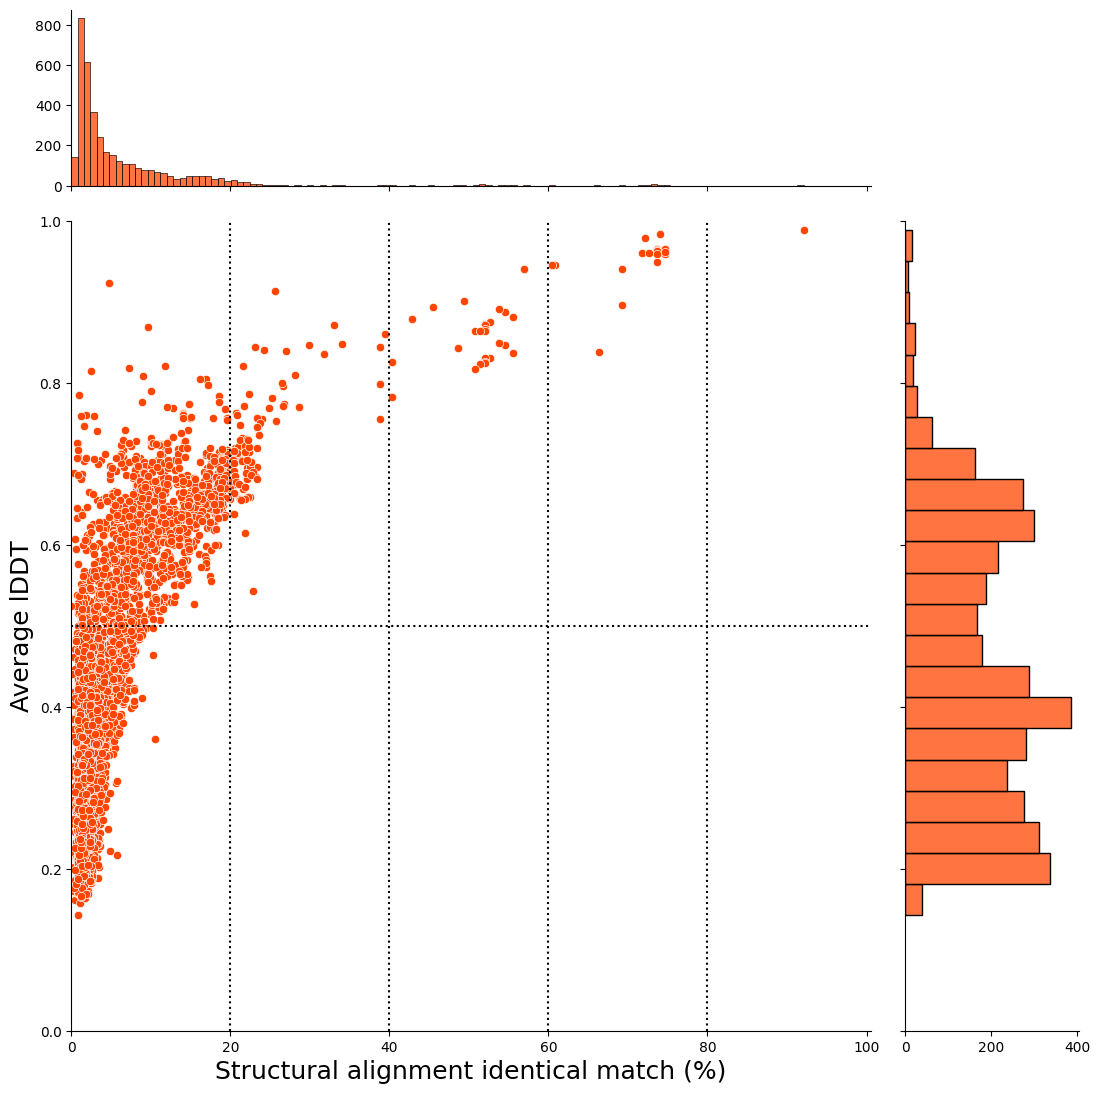

In [6]:
foldseek_filter_viz = foldseek_result.to_pandas()

sns.jointplot(
    data=foldseek_filter_viz,
    x="pident", # structural alignment identical match from foldseek result
    y="lddt",
    color="orangered",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(0,100.5)
plt.ylim(0,1)
plt.xlabel("Structural alignment identical match (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

# Save as PNG
plt.savefig(
    "foldseek_result_pident_lddt.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (3) Parse protein sequence pairwise alignment result (water and needle)

- package: EMBOSS:6.5.7--4
- Score Subsutitution Matrix: EBLOSUM30 (For considering remote similarity)
- Website: [EMBOSS](https://emboss.sourceforge.net/)
- needle document: [EMBOSS needle](https://emboss.sourceforge.net/apps/release/6.0/emboss/apps/needle.html)
- water document: [EMBOSS water](https://emboss.sourceforge.net/apps/cvs/emboss/apps/water.html)
- EMBL-EBI Webserver: [EMBOSS NEEDLE](https://www.ebi.ac.uk/jdispatcher/psa/emboss_needle)
- EMBL-EBI Webserver: [EMBOSS WATER](https://www.ebi.ac.uk/jdispatcher/psa/emboss_water)

- For pairs hit by Foldseek (structural alignment), we perform analysis on the sequence similarity observed upon alignment at the `protein sequence level`.
- In other words, it is performing an alignment again on the pair of sequences, not just the regions aligned by Foldseek.

&nbsp;

In [7]:
def parse_needle_water_result(file_path: str | pathlib.Path) -> dict:
    with open(file_path, "r", encoding="utf-8") as file:
        data = file.readlines()

    result = {
        "UniProt Accession": None,
        "foldseek hit": None,
        "Matrix": None,
        "Gap_penalty": None,
        "Extend_penalty": None,
        "Align_Length": None,
        "Identity": None,
        "Identity_percent": None,
        "Similarity": None,
        "Similarity_percent": None,
        "Gaps": None,
        "Gaps_percent": None,
        "Score": None,
        "Longest_Identity": None,
        "Longest_Similarity": None,
        "Shortest_Identity": None,
        "Shortest_Similarity": None,
    }

    for line in data:
        if line.startswith("# 1:"):
            result['UniProt Accession'] = line.split(":")[1].strip()
        elif line.startswith("# 2:"):
            result["foldseek hit"] = line.split(":")[1].strip()
        elif line.startswith("# Matrix:"):
            result["Matrix"] = line.split(":")[1].strip()
        elif line.startswith("# Gap_penalty:"):
            result["Gap_penalty"] = float(line.split(":")[1].strip())
        elif line.startswith("# Extend_penalty:"):
            result["Extend_penalty"] = float(line.split(":")[1].strip())
        elif line.startswith("# Length:"):
            result["Align_Length"] = int(line.split()[2])
        elif line.startswith("# Identity:"):
            result["Identity"] = line.split()[2]
            if m := re.search(r"\((.*?)%\)", line):
                result["Identity_percent"] = float(m.group(1))
        elif line.startswith("# Similarity:"):
            result["Similarity"] = line.split()[2]
            if m := re.search(r"\((.*?)%\)", line):
                result["Similarity_percent"] = float(m.group(1))
        elif line.startswith("# Gaps:"):
            result["Gaps"] = line.split()[2]
            if m := re.search(r"\((.*?)%\)", line):
                result["Gaps_percent"] = float(m.group(1))
        elif line.startswith("# Score:"):
            result["Score"] = float(line.split()[2])
        elif line.startswith("# Longest_Identity"):
            result["Longest_Identity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )
        elif line.startswith("# Longest_Similarity"):
            result["Longest_Similarity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )
        elif line.startswith("# Shortest_Identity"):
            result["Shortest_Identity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )
        elif line.startswith("# Shortest_Similarity"):
            result["Shortest_Similarity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )

    return result

In [8]:
water_result_dir = pathlib.Path(water_result_dir_path)
needle_result_dir = pathlib.Path(needle_result_dir_path)

# Initialize empty lists to store DataFrames
water_dfs = []
needle_dfs = []

# Collect all water results
for result_file in water_result_dir.glob("*_align.water"):
    parsed_data = parse_needle_water_result(result_file)
    water_dfs.append(pl.DataFrame([parsed_data]))

# Collect all needle results    
for result_file in needle_result_dir.glob("*_align.needle"):
    parsed_data = parse_needle_water_result(result_file)
    needle_dfs.append(pl.DataFrame([parsed_data]))

# Combine all results and sort only if there are results
water_result = (pl.concat(water_dfs, how='vertical')
                .sort(["UniProt Accession", "foldseek hit"]) 
                if water_dfs else pl.DataFrame()).with_columns(
                    pl.col("UniProt Accession").str.extract(r"AF-(.*?)-F1", 1).alias("UniProt Accession"), # add removing AF- prefix
                    pl.col("foldseek hit").str.extract(r"AF-(.*?)-F1", 1).alias("foldseek hit") # add removing AF- prefix
                )

needle_result = (pl.concat(needle_dfs, how='vertical')
                 .sort(["UniProt Accession", "foldseek hit"])
                 if needle_dfs else pl.DataFrame()).with_columns(
                    pl.col("UniProt Accession").str.extract(r"AF-(.*?)-F1", 1).alias("UniProt Accession"), # add removing AF- prefix
                    pl.col("foldseek hit").str.extract(r"AF-(.*?)-F1", 1).alias("foldseek hit") # add removing AF- prefix
                )

display(water_result)
display(needle_result)

UniProt Accession,foldseek hit,Matrix,Gap_penalty,Extend_penalty,Align_Length,Identity,Identity_percent,Similarity,Similarity_percent,Gaps,Gaps_percent,Score,Longest_Identity,Longest_Similarity,Shortest_Identity,Shortest_Similarity
str,str,str,f64,f64,i64,str,f64,str,f64,str,f64,f64,f64,f64,f64,f64
"""A0A0N7KC66""","""A5D8V6""","""EBLOSUM30""",10.0,0.5,480,"""82/480""",17.1,"""171/480""",35.6,"""175/480""",36.5,251.5,26.89,56.07,17.67,36.85
"""A0A0N7KC66""","""A8MQT2""","""EBLOSUM30""",10.0,0.5,605,"""110/605""",18.2,"""217/605""",35.9,"""209/605""",34.5,357.5,27.78,54.8,18.24,35.99
"""A0A0N7KC66""","""O00499""","""EBLOSUM30""",10.0,0.5,623,"""115/623""",18.5,"""223/623""",35.8,"""228/623""",36.6,345.5,29.11,56.46,19.39,37.61
"""A0A0N7KC66""","""O14503""","""EBLOSUM30""",10.0,0.5,426,"""85/426""",20.0,"""157/426""",36.9,"""152/426""",35.7,299.5,31.02,57.3,18.32,33.84
"""A0A0N7KC66""","""O60239""","""EBLOSUM30""",10.0,0.5,518,"""117/518""",22.6,"""199/518""",38.4,"""172/518""",33.2,335.5,33.82,57.51,25.22,42.89
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q9LGI2""","""Q99877""","""EBLOSUM30""",10.0,0.5,143,"""82/143""",57.3,"""107/143""",74.8,"""18/143""",12.6,514.0,65.6,85.6,53.59,69.93
"""Q9LGI2""","""Q99879""","""EBLOSUM30""",10.0,0.5,143,"""81/143""",56.6,"""106/143""",74.1,"""18/143""",12.6,512.0,64.8,84.8,52.94,69.28
"""Q9LGI2""","""Q99880""","""EBLOSUM30""",10.0,0.5,125,"""78/125""",62.4,"""100/125""",80.0,"""3/125""",2.4,500.0,63.93,81.97,50.98,65.36


UniProt Accession,foldseek hit,Matrix,Gap_penalty,Extend_penalty,Align_Length,Identity,Identity_percent,Similarity,Similarity_percent,Gaps,Gaps_percent,Score,Longest_Identity,Longest_Similarity,Shortest_Identity,Shortest_Similarity
str,str,str,f64,f64,i64,str,f64,str,f64,str,f64,f64,f64,f64,f64,f64
"""A0A0N7KC66""","""A5D8V6""","""EBLOSUM30""",10.0,0.5,512,"""82/512""",16.0,"""171/512""",33.4,"""205/512""",40.0,247.5,26.71,55.7,17.67,36.85
"""A0A0N7KC66""","""A8MQT2""","""EBLOSUM30""",10.0,0.5,664,"""112/664""",16.9,"""220/664""",33.1,"""261/664""",39.3,357.0,27.79,54.59,18.57,36.48
"""A0A0N7KC66""","""O00499""","""EBLOSUM30""",10.0,0.5,663,"""114/663""",17.2,"""222/663""",33.5,"""269/663""",40.6,341.5,28.93,56.35,19.22,37.44
"""A0A0N7KC66""","""O14503""","""EBLOSUM30""",10.0,0.5,587,"""88/587""",15.0,"""166/587""",28.3,"""298/587""",50.8,297.0,30.45,57.44,18.97,35.78
"""A0A0N7KC66""","""O60239""","""EBLOSUM30""",10.0,0.5,565,"""116/565""",20.5,"""198/565""",35.0,"""211/565""",37.3,329.5,32.77,55.93,25.0,42.67
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q9LGI2""","""Q99877""","""EBLOSUM30""",10.0,0.5,154,"""82/154""",53.2,"""107/154""",69.5,"""29/154""",18.8,514.0,65.6,85.6,53.59,69.93
"""Q9LGI2""","""Q99879""","""EBLOSUM30""",10.0,0.5,154,"""81/154""",52.6,"""106/154""",68.8,"""29/154""",18.8,512.0,64.8,84.8,52.94,69.28
"""Q9LGI2""","""Q99880""","""EBLOSUM30""",10.0,0.5,157,"""78/157""",49.7,"""100/157""",63.7,"""35/157""",22.3,500.0,63.93,81.97,50.98,65.36


In [9]:
alignment_result = water_result.join(
    needle_result,
    on=["UniProt Accession", "foldseek hit"],
    how="inner",
    coalesce=True,
    suffix="_needle"
).rename(
    {
        "Align_Length": "Align_Length_water",
        "Identity": "Identity_water",
        "Identity_percent": "Identity_percent_water",
        "Similarity": "Similarity_water",
        "Similarity_percent": "Similarity_percent_water",
        "Gaps": "Gaps_water",
        "Gaps_percent": "Gaps_percent_water",
        "Longest_Identity": "Longest_Identity_water",
        "Longest_Similarity": "Longest_Similarity_water",
        "Shortest_Identity": "Shortest_Identity_water",
        "Shortest_Similarity": "Shortest_Similarity_water",
        "Score": "Score_water"
    }
).select(
    [
        "UniProt Accession",
        "foldseek hit",
        "Align_Length_water",
        "Align_Length_needle",
        "Identity_water",
        "Identity_needle",
        "Identity_percent_water",
        "Identity_percent_needle",
        "Similarity_percent_water",
        "Similarity_percent_needle",
        "Gaps_water",
        "Gaps_needle",
        "Gaps_percent_water",
        "Gaps_percent_needle",
        "Shortest_Identity_water",
        "Shortest_Identity_needle",
        "Longest_Identity_water",
        "Longest_Identity_needle",
        "Shortest_Similarity_water",
        "Shortest_Similarity_needle",
        "Longest_Similarity_water",
        "Longest_Similarity_needle",
        "Score_water",
        "Score_needle",
        "Gap_penalty",
        "Extend_penalty",
        "Matrix"
    ]
)

display(alignment_result)

UniProt Accession,foldseek hit,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_needle,Gaps_percent_water,Gaps_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,i64,i64,str,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""A0A0N7KC66""","""A5D8V6""",480,512,"""82/480""","""82/512""",17.1,16.0,35.6,33.4,"""175/480""","""205/512""",36.5,40.0,17.67,17.67,26.89,26.71,36.85,36.85,56.07,55.7,251.5,247.5,10.0,0.5,"""EBLOSUM30"""
"""A0A0N7KC66""","""A8MQT2""",605,664,"""110/605""","""112/664""",18.2,16.9,35.9,33.1,"""209/605""","""261/664""",34.5,39.3,18.24,18.57,27.78,27.79,35.99,36.48,54.8,54.59,357.5,357.0,10.0,0.5,"""EBLOSUM30"""
"""A0A0N7KC66""","""O00499""",623,663,"""115/623""","""114/663""",18.5,17.2,35.8,33.5,"""228/623""","""269/663""",36.6,40.6,19.39,19.22,29.11,28.93,37.61,37.44,56.46,56.35,345.5,341.5,10.0,0.5,"""EBLOSUM30"""
"""A0A0N7KC66""","""O14503""",426,587,"""85/426""","""88/587""",20.0,15.0,36.9,28.3,"""152/426""","""298/587""",35.7,50.8,18.32,18.97,31.02,30.45,33.84,35.78,57.3,57.44,299.5,297.0,10.0,0.5,"""EBLOSUM30"""
"""A0A0N7KC66""","""O60239""",518,565,"""117/518""","""116/565""",22.6,20.5,38.4,35.0,"""172/518""","""211/565""",33.2,37.3,25.22,25.0,33.82,32.77,42.89,42.67,57.51,55.93,335.5,329.5,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q9LGI2""","""Q99877""",143,154,"""82/143""","""82/154""",57.3,53.2,74.8,69.5,"""18/143""","""29/154""",12.6,18.8,53.59,53.59,65.6,65.6,69.93,69.93,85.6,85.6,514.0,514.0,10.0,0.5,"""EBLOSUM30"""
"""Q9LGI2""","""Q99879""",143,154,"""81/143""","""81/154""",56.6,52.6,74.1,68.8,"""18/143""","""29/154""",12.6,18.8,52.94,52.94,64.8,64.8,69.28,69.28,84.8,84.8,512.0,512.0,10.0,0.5,"""EBLOSUM30"""
"""Q9LGI2""","""Q99880""",125,157,"""78/125""","""78/157""",62.4,49.7,80.0,63.7,"""3/125""","""35/157""",2.4,22.3,50.98,50.98,63.93,63.93,65.36,65.36,81.97,81.97,500.0,500.0,10.0,0.5,"""EBLOSUM30"""


&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (4) Integrate foldseek result and pairwise alignment result

- This time, **exclude the ones that are null in pairwise alignment result, which means the current UniProt entry is obsolete**

In [10]:
join_foldseek = foldseek_result.join(
    alignment_result,
    on=["UniProt Accession", "foldseek hit"],
    how="left",
    coalesce=True
).filter( # filter out null alignment result (this means current UniProt entry is obsolete)
    pl.col("Align_Length_water").is_not_null() & 
    pl.col("Align_Length_needle").is_not_null()
).unique()

join_foldseek.write_csv(
    "foldseek_result_join_alignment_result_all.tsv",
    separator='\t'
)


display(join_foldseek)

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,qaln,taln,mismatch,lddtfull,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_needle,Gaps_percent_water,Gaps_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,str,i64,str,i64,i64,str,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""Os07g0655300""","""Q8H3E5""","""Q08397""",0.1982,0.034,33,1.5,0.015,9,12,394,434,226,574,574,580,0.882,0.608,0.2673,0.2324,0.1861,0.2721,6.825,"""SSSSPAA----------AAAAVGRPFPPIA…","""YPYQPRARYEEYGGGEE----------LPE…",143,"""0.312,0.406,0.531,0.531,0.531,…",506,664,"""106/506""","""106/664""",20.9,16.0,37.2,28.3,"""168/506""","""320/664""",33.2,48.2,18.47,18.47,31.36,30.81,32.75,32.75,55.62,54.65,359.5,354.5,10.0,0.5,"""EBLOSUM30"""
"""Os11g0133800""","""A0A0P0XYE1""","""Q9UIJ5""",0.5439,0.411,21,11.3,0.113,49,32,372,469,12,367,367,433,0.727,0.97,0.629,0.4919,0.6176,0.6625,4.044,"""NI--FLCGGRLIIGPDAASLLLSMFLILGP…","""RRCR--------RVLYWIPVVFITLLLGWS…",215,"""0.073,0.145,0.208,0.141,0.194,…",426,525,"""100/426""","""103/525""",23.5,19.6,43.0,35.8,"""127/426""","""214/525""",29.8,40.8,21.32,21.96,33.44,33.12,39.02,40.09,61.2,60.45,609.0,607.5,10.0,0.5,"""EBLOSUM30"""
"""Os01g0810800""","""B7FAC9""","""Q05397""",0.3457,0.15,60,4.6,0.046,67,47,937,937,40,1038,1052,1461,0.951,0.95,0.4664,0.3707,0.3348,0.3878,6.406,"""VDCG------------------LTNRSTYN…","""FHYFESNSEPTTWASIIRHGDA--------…",362,"""0.153,0.190,0.155,0.155,0.141,…",940,1316,"""191/940""","""192/1316""",20.3,14.6,38.2,27.7,"""276/940""","""643/1316""",29.4,48.9,18.16,18.25,28.77,28.53,34.13,34.6,54.07,54.09,754.0,753.0,10.0,0.5,"""EBLOSUM30"""
"""Os11g0436450""","""A0A0N7KSV2""","""P56470""",0.2673,0.076,23,2.7,0.027,11,43,270,270,4,308,323,406,0.844,0.944,0.3152,0.3059,0.2665,0.3454,6.041,"""VSAA-EKKLVAAAAGLPS---------ELL…","""VPAPGYQPTYNPTLPYYQPIPGGLNVG---…",116,"""0.115,0.158,0.183,0.205,0.406,…",321,384,"""50/321""","""51/384""",15.6,13.3,31.8,27.6,"""120/321""","""175/384""",37.4,45.6,15.48,15.79,24.88,24.4,31.58,32.82,50.75,50.72,196.0,188.5,10.0,0.5,"""EBLOSUM30"""
"""Os03g0811600""","""Q0DMF1""","""O43508""",0.2282,0.051,24,0.9,0.009,3,1,167,204,5,234,249,308,0.819,0.924,0.3416,0.2671,0.2302,0.3087,5.722,"""MASSGGAAISAGPTP-PS------------…","""RSQRRRGRRGEPGTALLVPLALGLGLALAC…",86,"""1.000,0.950,0.958,1.000,0.969,…",218,295,"""46/218""","""47/295""",21.1,15.9,36.7,27.8,"""63/218""","""137/295""",28.9,46.4,18.47,18.88,29.68,29.75,32.13,32.93,51.61,51.9,180.0,178.5,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Os03g0266700""","""A0A8J8XMS3""","""Q6P597""",0.2461,0.069,14,3.2,0.032,14,143,313,394,18,423,504,433,0.434,0.806,0.534,0.2828,0.229,0.5588,4.855,"""SAPLEDARLLTYRYQRIRQDMESQIADVMR…","""LSPEELVRQTRQVVQGLEALRAEHHGLAGH…",130,"""0.097,0.290,0.382,0.268,0.257,…",535,569,"""105/535""","""105/569""",19.6,18.5,34.4,32.2,"""211/535""","""240/569""",39.4,42.2,20.83,20.83,32.41,31.91,36.51,36.31,56.79,55.62,314.5,313.5,10.0,0.5,"""EBLOSUM30"""
"""Os01g0810800""","""B7FAC9""","""P29322""",0.2618,0.069,19,13.8,0.138,69,537,936,937,592,974,1005,499,0.427,0.381,0.6346,0.2734,0.2558,0.6273,4.45,"""KKN------------------------TRT…","""PVFLPLHHPPGKLPEPQFYAEPHTYEE---…",215,"""0.095,0.100,0.125,0.161,0.308,…",1124,1200,"""218/1124""","""219/1200""",19.4,18.2,36.7,34.4,"""384/1124""","""458/1200""",34.2,38.2,21.69,21.79,29.46,29.

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (5) Create Scatter Plot for all hits (x-axis: Similarity_percent_needle) Global alignment

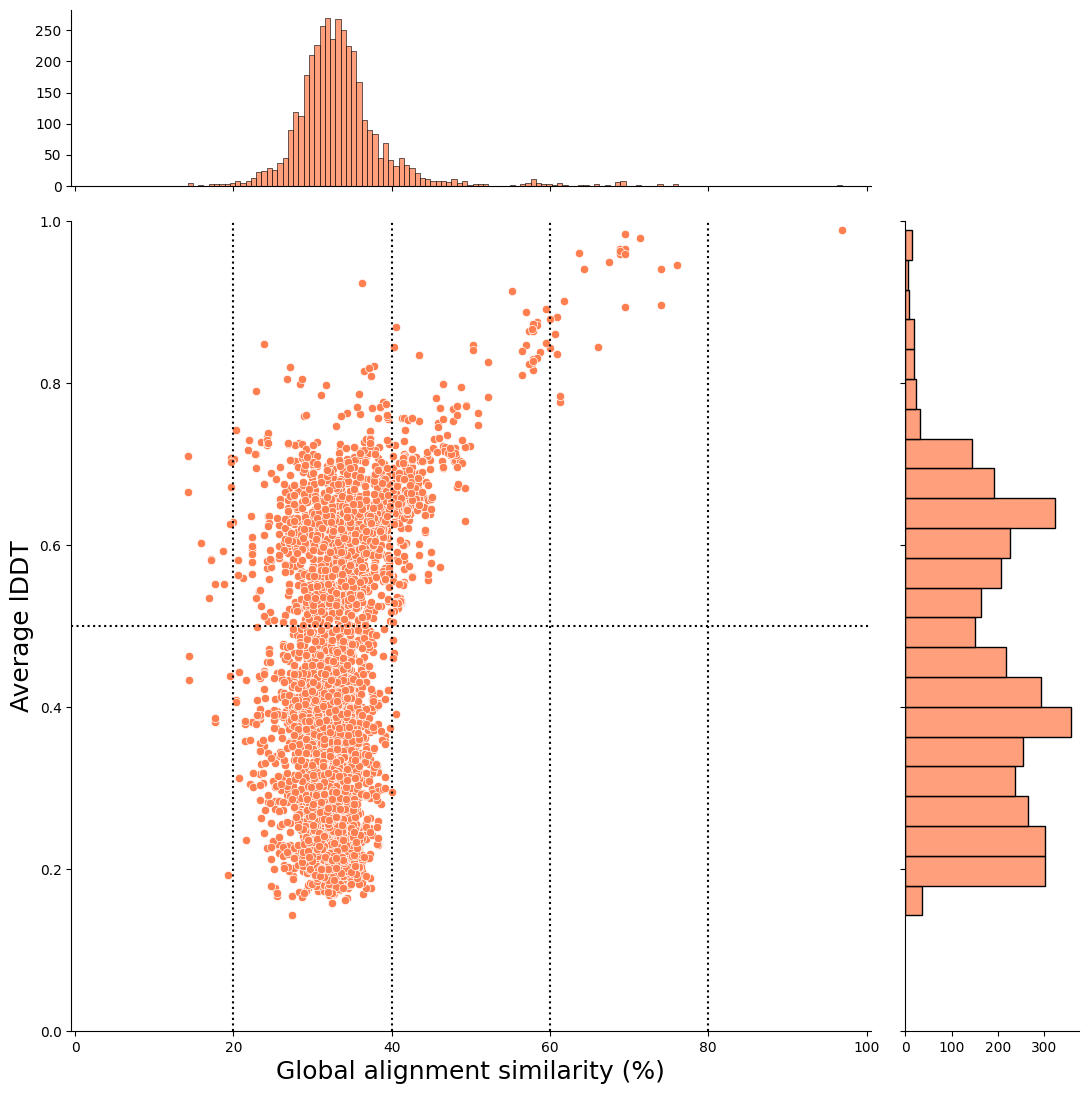

In [11]:
foldseek_filter_viz2 = join_foldseek.to_pandas()

sns.jointplot(
    data=foldseek_filter_viz2,
    x="Similarity_percent_needle",
    y="lddt",
    color="coral",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(-0.5,100.5)
plt.ylim(0,1)
plt.xlabel("Global alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_needle_lddt_all.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## Create Scatter Plot for all hits (x-axis: Similarity_percent_water) Local Alignment

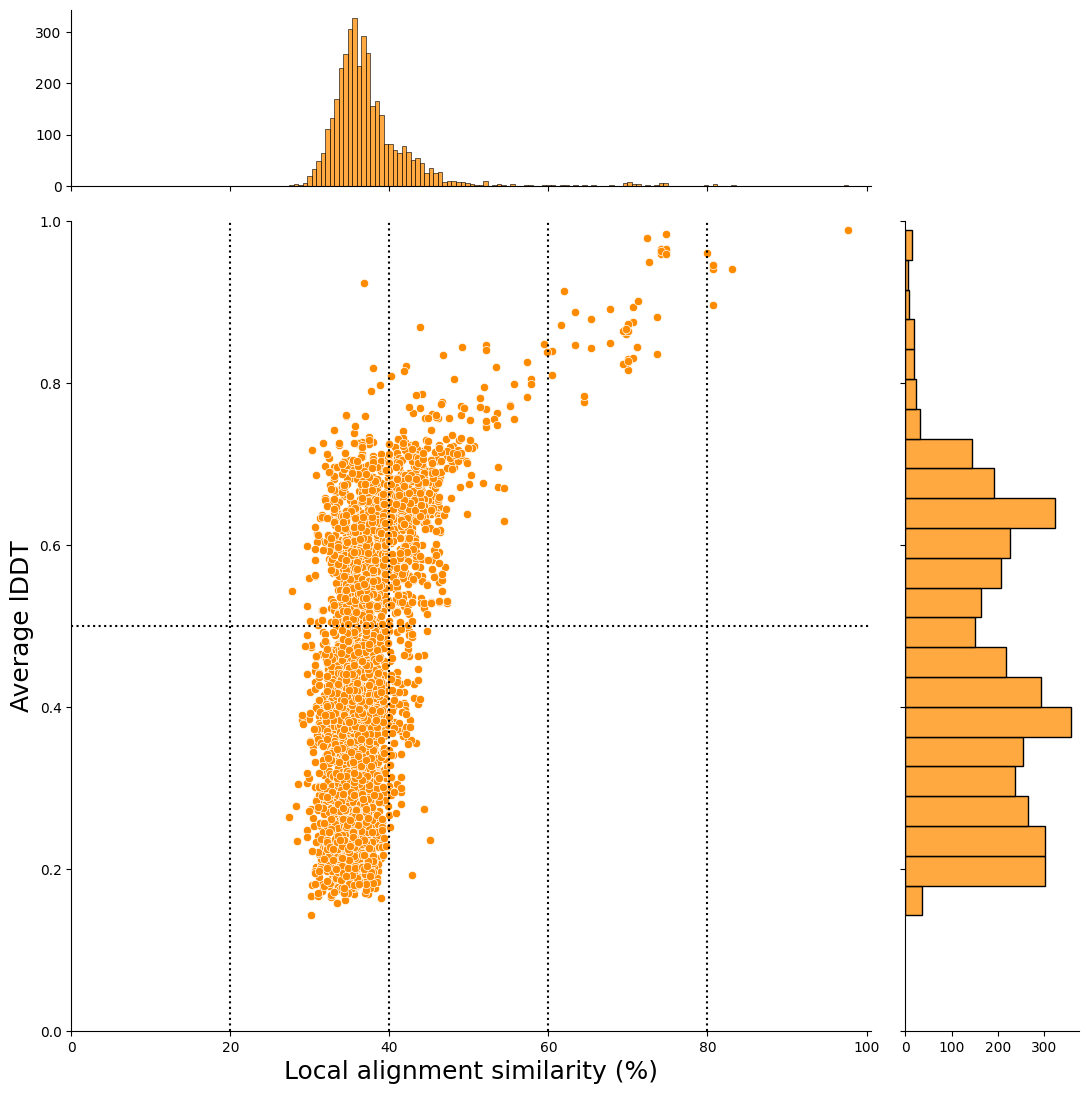

In [12]:
foldseek_filter_viz2 = join_foldseek.to_pandas()

sns.jointplot(
    data=foldseek_filter_viz2,
    x="Similarity_percent_water", # local alignment similarity
    y="lddt",
    color="darkorange",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(0,100.5)
plt.ylim(0,1)
plt.xlabel("Local alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_water_lddt_all.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (6) Counting foldseek hits in Gene level

In [13]:
all_gene_list = pl.read_csv(
    query_gene_list_tsv_path,
    separator='\t'
).select(
    "From"
).unique()

hit_count = all_gene_list.join(
    join_foldseek,
    on="From",
    how="left",
    coalesce=True
).group_by("From", maintain_order=True).agg(
    (pl.col("foldseek hit").count().alias("target hit count (gene level vs uniprot accession)")),
    (pl.col("foldseek hit").is_null().all().alias("foldseek no hit"))
).sort(
    ["target hit count (gene level vs uniprot accession)"], descending=True
)

hit_count.write_csv(
    "foldseek_result_gene_level_hit_count_all.tsv",
    separator='\t'
)

display(hit_count)

From,target hit count (gene level vs uniprot accession),foldseek no hit
str,u32,bool
"""Os03g0266700""",330,false
"""Os01g0924300""",265,false
"""Os02g0816000""",212,false
"""Os01g0810800""",201,false
"""Os07g0655300""",183,false
…,…,…
"""Os01g0664500""",0,true
"""Os06g0481900""",0,true
"""Os08g0213400""",0,true


&nbsp;

&nbsp;

&nbsp;

# Caution:

- The filtering steps that are executed below can be changed freely.

&nbsp;

## (7) Filtering Condition1

- alignment coverage `>= 0.5`

In [14]:
condition1 = join_foldseek.filter(
        (pl.col("qcov") >= 0.5) &
        (pl.col("tcov") >= 0.5)
    ).sort(
        by=["From", "foldseek hit", "UniProt Accession"], # sort by From, foldseek hit, UniProt Accession
        descending=[False, False, False]
    )

condition1_rm = condition1.filter(
        (pl.col("qcov") < 0.5) |
        (pl.col("tcov") < 0.5)
    )

print(condition1.group_by(["From"], maintain_order=True).n_unique())
display(condition1)

shape: (64, 52)
┌────────────┬────────────┬────────────┬────────┬───┬────────────┬────────────┬───────────┬────────┐
│ From       ┆ UniProt    ┆ foldseek   ┆ evalue ┆ … ┆ Score_need ┆ Gap_penalt ┆ Extend_pe ┆ Matrix │
│ ---        ┆ Accession  ┆ hit        ┆ ---    ┆   ┆ le         ┆ y          ┆ nalty     ┆ ---    │
│ str        ┆ ---        ┆ ---        ┆ u32    ┆   ┆ ---        ┆ ---        ┆ ---       ┆ u32    │
│            ┆ u32        ┆ u32        ┆        ┆   ┆ u32        ┆ u32        ┆ u32       ┆        │
╞════════════╪════════════╪════════════╪════════╪═══╪════════════╪════════════╪═══════════╪════════╡
│ Os01g01048 ┆ 3          ┆ 33         ┆ 39     ┆ … ┆ 33         ┆ 1          ┆ 1         ┆ 1      │
│ 00         ┆            ┆            ┆        ┆   ┆            ┆            ┆           ┆        │
│ Os01g01523 ┆ 1          ┆ 33         ┆ 32     ┆ … ┆ 27         ┆ 1          ┆ 1         ┆ 1      │
│ 00         ┆            ┆            ┆        ┆   ┆            ┆         

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,qaln,taln,mismatch,lddtfull,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_needle,Gaps_percent_water,Gaps_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,str,i64,str,i64,i64,str,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""Os01g0104800""","""A0A0N7KC66""","""A5D8V6""",0.1402,0.008,30,1.5,0.015,8,20,414,464,19,223,355,501,0.851,0.577,0.4196,0.1357,0.1652,0.2314,7.339,"""KMKEEFAVL-SRDEKMGVLDSSAPELVGLL…","""SEAIDQLALE--------S-----------…",91,"""0.469,0.380,0.344,0.444,0.352,…",480,512,"""82/480""","""82/512""",17.1,16.0,35.6,33.4,"""175/480""","""205/512""",36.5,40.0,17.67,17.67,26.89,26.71,36.85,36.85,56.07,55.7,251.5,247.5,10.0,0.5,"""EBLOSUM30"""
"""Os01g0104800""","""Q658C6""","""A6NNM8""",0.1357,0.01,56,0.3,0.003,3,56,589,645,190,752,815,945,0.828,0.691,0.3139,0.1544,0.1288,0.1763,8.181,"""HPVFDL------------------------…","""YGRQRKARTYICKPDSGCQGRGIFITRNPR…",149,"""0.194,0.344,0.438,0.438,0.306,…",864,878,"""152/864""","""152/878""",17.6,17.3,35.8,35.1,"""287/864""","""296/878""",33.2,33.7,18.65,18.65,26.34,26.12,37.91,37.79,53.55,52.92,483.5,480.5,10.0,0.5,"""EBLOSUM30"""
"""Os01g0104800""","""A0A0N7KC66""","""O00499""",0.235,0.057,29,0.8,0.008,6,9,418,464,15,492,593,716,0.884,0.806,0.5208,0.2699,0.2192,0.2977,6.245,"""PDGEHSFETYVKMKEEFAVL--SRDEKMGV…","""ASNVQKKLTRAQEKVLQKLGKA---DE-TK…",166,"""0.250,0.341,0.386,0.481,0.617,…",623,663,"""115/623""","""114/663""",18.5,17.2,35.8,33.5,"""228/623""","""269/663""",36.6,40.6,19.39,19.22,29.11,28.93,37.61,37.44,56.46,56.35,345.5,341.5,10.0,0.5,"""EBLOSUM30"""
"""Os01g0104800""","""Q657Z6""","""O43290""",0.13,0.01,28,1.0,0.01,8,31,566,645,110,557,800,841,0.831,0.56,0.4276,0.1466,0.1241,0.1905,8.001,"""IDAFHKHRD---------------------…","""TSSGDASSLSIEETNKLRAKLGLKPLEVNA…",135,"""0.094,0.139,0.196,0.172,0.206,…",818,886,"""171/818""","""171/886""",20.9,19.3,37.5,34.9,"""262/818""","""327/886""",32.0,36.9,21.38,21.38,30.76,30.59,38.38,38.62,55.22,55.28,531.5,527.5,10.0,0.5,"""EBLOSUM30"""
"""Os01g0104800""","""Q658C6""","""O43290""",0.1574,0.014,32,1.1,0.011,9,46,601,645,83,560,800,853,0.862,0.598,0.4355,0.1797,0.1521,0.2199,8.098,"""HDM---------------------------…","""RSQAEPSERRVKREKRDDGYEAAASSKTSS…",172,"""0.188,0.250,0.188,0.250,0.250,…",818,886,"""171/818""","""171/886""",20.9,19.3,37.5,34.9,"""262/818""","""327/886""",32.0,36.9,21.38,21.38,30.76,30.59,38.38,38.62,55.22,55.28,531.5,527.5,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Os12g0586300""","""Q2QMY1""","""Q8NEF9""",0.1931,0.024,20,1.8,0.018,11,29,364,395,1,364,429,585,0.851,0.848,0.486,0.2096,0.1958,0.238,5.814,"""MLAARTATGALARAGGGEAAAAAAAAARFE…","""M--AQ-PG----------------T--LNL…",104,"""0.113,0.073,0.236,0.356,0.281,…",412,498,"""77/412""","""72/498""",18.7,14.5,38.8,33.3,"""115/412""","""172/498""",27.9,34.5,17.95,16.78,25.93,22.09,37.3,38.69,53.87,50.92,255.5,254.5,10.0,0.5,"""EBLOSUM30"""
"""Os12g0586300""","""Q0IM90""","""Q96B86""",0.2112,0.04,20,2.3,0.023,12,22,325,395,50,387,450,518,0.77,0.751,0.4605,0.2324,0.2081,0.2877,5.613,"""LG--GVDMRMLAARTATGALARAGGGEAAA…","""ILKC---NS-EFWSATSGSHA-----P--A…",112,"""0.259,0.073,0.351,0.256,0.412,…",438,522,"""82/438""","""81/522""",18.7,15.5,35.8,31.0,"""137/438""","""199/522""",31.3,38.1,18.22,18.0,27.24,25.08,34.89,36.0,52.16,50.15,2

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (8) Filtering Condition2

- If there are hits with the same target for the same gene-derived UniProt ID, the one with the highest qcov is selected, and if the qcov is the same, the one with the highest lDDT is selected.
- **Note that in this study, we leave the states with the same foldseek hit even if the rice genes are different.**

In [15]:
condition2 = condition1.sort(
    by=["qcov", "lddt"],
    descending=[True, True]
).group_by(
    ["From", "foldseek hit"],
    maintain_order=True
).agg(
    pl.all().first()
).sort(
    by=["From", "UniProt Accession", "foldseek hit"],
    descending=[False, False, False]
).select(
    "From",
    "UniProt Accession",
    "foldseek hit",
    "evalue",
    "prob",
    "gapopen",
    "pident",
    "fident",
    "nident",
    "qstart",
    "qend",
    "qlen",
    "tstart",
    "tend",
    "tlen",
    "alnlen",
    "qcov",
    "tcov",
    "lddt",
    "qtmscore",
    "ttmscore",
    "alntmscore",
    "rmsd",
    "mismatch",
    "Align_Length_water",
    "Align_Length_needle",
    "Identity_water",
    "Identity_needle",
    "Identity_percent_water",
    "Identity_percent_needle",
    "Similarity_percent_water",
    "Similarity_percent_needle",
    "Shortest_Identity_water",
    "Shortest_Identity_needle",
    "Longest_Identity_water",
    "Longest_Identity_needle",
    "Shortest_Similarity_water",
    "Shortest_Similarity_needle",
    "Longest_Similarity_water",
    "Longest_Similarity_needle",
    "Gaps_water",
    "Gaps_percent_water",
    "Gaps_needle",
    "Gaps_percent_needle",
    "Score_water",
    "Score_needle",
    "Gap_penalty",
    "Extend_penalty",
    "Matrix"
)

display(condition2)

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,mismatch,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,f64,f64,f64,f64,str
"""Os01g0104800""","""A0A0N7KC66""","""A5D8V6""",0.1402,0.008,30,1.5,0.015,8,20,414,464,19,223,355,501,0.851,0.577,0.4196,0.1357,0.1652,0.2314,7.339,91,480,512,"""82/480""","""82/512""",17.1,16.0,35.6,33.4,17.67,17.67,26.89,26.71,36.85,36.85,56.07,55.7,"""175/480""",36.5,"""205/512""",40.0,251.5,247.5,10.0,0.5,"""EBLOSUM30"""
"""Os01g0104800""","""A0A0N7KC66""","""O00499""",0.235,0.057,29,0.8,0.008,6,9,418,464,15,492,593,716,0.884,0.806,0.5208,0.2699,0.2192,0.2977,6.245,166,623,663,"""115/623""","""114/663""",18.5,17.2,35.8,33.5,19.39,19.22,29.11,28.93,37.61,37.44,56.46,56.35,"""228/623""",36.6,"""269/663""",40.6,345.5,341.5,10.0,0.5,"""EBLOSUM30"""
"""Os01g0104800""","""A0A0N7KC66""","""P26038""",0.1507,0.014,17,1.1,0.011,7,53,392,464,82,470,577,613,0.733,0.674,0.4283,0.1711,0.1446,0.218,6.751,109,490,653,"""105/490""","""108/653""",21.4,16.5,43.1,32.9,18.2,18.72,28.15,27.84,36.57,37.26,56.57,55.41,"""117/490""",23.9,"""265/653""",40.6,378.5,375.0,10.0,0.5,"""EBLOSUM30"""
"""Os01g0104800""","""A0A0N7KC66""","""P30556""",0.2329,0.029,12,1.3,0.013,8,4,409,464,19,329,359,585,0.875,0.866,0.5188,0.2177,0.2699,0.3046,5.343,124,438,535,"""73/438""","""73/535""",16.7,13.6,34.2,28.0,15.73,15.73,25.89,25.35,32.33,32.33,53.19,52.08,"""156/438""",35.6,"""247/535""",46.2,218.5,212.5,10.0,0.5,"""EBLOSUM30"""
"""Os01g0104800""","""A0A0N7KC66""","""Q13772""",0.1593,0.016,37,0.9,0.009,7,93,411,464,26,598,614,746,0.688,0.933,0.3813,0.187,0.1521,0.2411,7.956,139,592,684,"""112/592""","""114/684""",18.9,16.7,37.8,33.3,18.24,18.57,29.17,28.93,36.48,37.13,58.33,57.87,"""208/592""",35.1,"""290/684""",42.4,328.0,322.5,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Os12g0586300""","""Q2QMY1""","""A5D8V6""",0.1783,0.016,4,1.5,0.015,7,39,315,395,90,355,355,458,0.701,0.749,0.5999,0.1756,0.1928,0.2493,4.662,78,449,488,"""84/449""","""84/488""",18.7,17.2,32.3,29.9,21.27,21.27,32.56,32.06,36.71,36.96,56.2,55.73,"""191/449""",42.5,"""226/488""",46.3,286.0,283.0,10.0,0.5,"""EBLOSUM30"""
"""Os12g0586300""","""Q2QMY1""","""O14770""",0.17,0.02,14,3.1,0.031,15,178,386,395,13,379,477,478,0.529,0.769,0.5612,0.1907,0.1618,0.3227,5.385,83,461,533,"""83/461""","""84/533""",18.0,15.8,34.3,30.2,17.4,17.61,25.46,24.78,33.12,33.75,48.47,47.49,"""135/461""",29.3,"""194/533""",36.4,284.5,272.5,10.0,0.5,"""EBLOSUM30"""
"""Os12g0586300""","""Q2QMY1""","""Q8NCA5""",0.1932,0.034,33,2.4,0.024,14,7,374,395,1,341,518,575,0.932,0.658,0.4301,0.2257,0.1815,0.2526,6.689,120,510,564,"""105/510""","""107/564""",20.6,19.0,34.9,31.6,20.27,20.66,30.43,30.66,34.36,34.36,51.59,51.0,"""165/510""",32.4,"""215/564""",38.1,344.0,343.0,10.0,0.5,"""EBLOSUM30"""


&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (9) Filtering Condition3

- Select hits that can be converted to Ensembl gene id and HGNC Gene nomenclature with TogoID API
- https://togoid.dbcls.jp/

In [16]:
togoid_convert = pl.read_csv(
    togoid_convert_tsv_path,
    separator='\t'
).rename(
    {
        "uniprot_id" : "foldseek hit"
    }
).filter(
    pl.col("ensembl_gene_id").is_not_null() &
    pl.col("hgnc_symbol_id").is_not_null() # add HGNC Gene nomenclature information filtering condition
).sort(
    by=["foldseek hit"],
    descending=[False]
)

display(togoid_convert)

foldseek hit,ensembl_protein_id,ensembl_transcript_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id
str,str,str,str,i64,str
"""A0A075B6U4""","""ENSP00000443297""","""ENST00000390429""","""ENSG00000211781""",12145,"""TRAV7"""
"""A0A075B759""","""ENSP00000463419""","""ENST00000581164""","""ENSG00000271567""",33997,"""PPIAL4E"""
"""A0A075B767""","""ENSP00000464619""","""ENST00000584068""","""ENSG00000270339""",53889,"""PPIAL4H"""
"""A0A087X1G2""","""ENSP00000484181""","""ENST00000620247""","""ENSG00000273513""",51245,"""TBC1D3K"""
"""A0A096LPK9""","""ENSP00000485668""","""ENST00000623441""","""ENSG00000279408""",55110,"""OR4N4C"""
…,…,…,…,…,…
"""Q9Y6S9""","""ENSP00000452027""","""ENST00000555647""","""ENSG00000198208""",20222,"""RPS6KL1"""
"""Q9Y6S9""","""ENSP00000450567""","""ENST00000557413""","""ENSG00000198208""",20222,"""RPS6KL1"""
"""Q9Y6W3""","""ENSP00000253693""","""ENST00000253693""","""ENSG00000131375""",1484,"""CAPN7"""


In [17]:
condition3 = condition2.join(
    togoid_convert,
    on="foldseek hit",
    how="left",
    coalesce=True
).drop(
    [
        "ensembl_transcript_id",
        "hgnc_id"
    ]
).filter( 
    pl.col("ensembl_gene_id").is_not_null() &
    pl.col("hgnc_symbol_id").is_not_null() # add HGNC Gene nomenclature information filtering condition
).select(
    [
        "From",
        "UniProt Accession",
        "foldseek hit",
        "ensembl_protein_id",
        "ensembl_gene_id",
        "hgnc_symbol_id",
        "evalue",
        "prob",
        "gapopen",
        "pident",
        "fident",
        "nident",
        "qstart",
        "qend",
        "qlen",
        "tstart",
        "tend",
        "tlen",
        "alnlen",
        "mismatch",
        "qcov",
        "tcov",
        "rmsd",
        "lddt",
        "qtmscore",
        "ttmscore",
        "alntmscore",
        "Align_Length_water",
        "Align_Length_needle",
        "Identity_water",
        "Identity_percent_water",
        "Identity_percent_needle",
        "Similarity_percent_water",
        "Similarity_percent_needle",
        "Shortest_Identity_water",
        "Shortest_Identity_needle",
        "Longest_Identity_water",
        "Longest_Identity_needle",
        "Shortest_Similarity_water",
        "Shortest_Similarity_needle",
        "Longest_Similarity_water",
        "Longest_Similarity_needle",
        "Gaps_water",
        "Gaps_percent_water",
        "Gaps_needle",
        "Gaps_percent_needle",
        "Score_water",
        "Score_needle",
        "Gap_penalty",
        "Extend_penalty",
        "Matrix"
    ]
).sort(
    by=["From", "foldseek hit", "UniProt Accession"], # sort by From, foldseek hit, UniProt Accession (change order)
    descending=[False, False, False]
)

condition3.write_csv(
    "foldseek_result_join_alignment_result_filter.tsv",
    separator='\t'
)

display(condition3)

From,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,Align_Length_water,Align_Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,f64,f64,f64,f64,str
"""Os01g0104800""","""A0A0N7KC66""","""A5D8V6""","""ENSP00000301765""","""ENSG00000167987""","""VPS37C""",0.1402,0.008,30,1.5,0.015,8,20,414,464,19,223,355,501,91,0.851,0.577,7.339,0.4196,0.1357,0.1652,0.2314,480,512,"""82/480""",17.1,16.0,35.6,33.4,17.67,17.67,26.89,26.71,36.85,36.85,56.07,55.7,"""175/480""",36.5,"""205/512""",40.0,251.5,247.5,10.0,0.5,"""EBLOSUM30"""
"""Os01g0104800""","""Q658C6""","""A6NNM8""","""ENSP00000491066""","""ENSG00000213471""","""TTLL13""",0.1357,0.01,56,0.3,0.003,3,56,589,645,190,752,815,945,149,0.828,0.691,8.181,0.3139,0.1544,0.1288,0.1763,864,878,"""152/864""",17.6,17.3,35.8,35.1,18.65,18.65,26.34,26.12,37.91,37.79,53.55,52.92,"""287/864""",33.2,"""296/878""",33.7,483.5,480.5,10.0,0.5,"""EBLOSUM30"""
"""Os01g0104800""","""A0A0N7KC66""","""O00499""","""ENSP00000259238""","""ENSG00000136717""","""BIN1""",0.235,0.057,29,0.8,0.008,6,9,418,464,15,492,593,716,166,0.884,0.806,6.245,0.5208,0.2699,0.2192,0.2977,623,663,"""115/623""",18.5,17.2,35.8,33.5,19.39,19.22,29.11,28.93,37.61,37.44,56.46,56.35,"""228/623""",36.6,"""269/663""",40.6,345.5,341.5,10.0,0.5,"""EBLOSUM30"""
"""Os01g0104800""","""A0A0N7KC66""","""O00499""","""ENSP00000316779""","""ENSG00000136717""","""BIN1""",0.235,0.057,29,0.8,0.008,6,9,418,464,15,492,593,716,166,0.884,0.806,6.245,0.5208,0.2699,0.2192,0.2977,623,663,"""115/623""",18.5,17.2,35.8,33.5,19.39,19.22,29.11,28.93,37.61,37.44,56.46,56.35,"""228/623""",36.6,"""269/663""",40.6,345.5,341.5,10.0,0.5,"""EBLOSUM30"""
"""Os01g0104800""","""A0A0N7KC66""","""O00499""","""ENSP00000315411""","""ENSG00000136717""","""BIN1""",0.235,0.057,29,0.8,0.008,6,9,418,464,15,492,593,716,166,0.884,0.806,6.245,0.5208,0.2699,0.2192,0.2977,623,663,"""115/623""",18.5,17.2,35.8,33.5,19.39,19.22,29.11,28.93,37.61,37.44,56.46,56.35,"""228/623""",36.6,"""269/663""",40.6,345.5,341.5,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Os12g0586300""","""Q0IM90""","""Q96B86""","""ENSP00000404442""","""ENSG00000182175""","""RGMA""",0.2112,0.04,20,2.3,0.023,12,22,325,395,50,387,450,518,112,0.77,0.751,5.613,0.4605,0.2324,0.2081,0.2877,438,522,"""82/438""",18.7,15.5,35.8,31.0,18.22,18.0,27.24,25.08,34.89,36.0,52.16,50.15,"""137/438""",31.3,"""199/522""",38.1,279.5,275.0,10.0,0.5,"""EBLOSUM30"""
"""Os12g0586300""","""Q0IM90""","""Q96B86""","""ENSP00000330005""","""ENSG00000182175""","""RGMA""",0.2112,0.04,20,2.3,0.023,12,22,325,395,50,387,450,518,112,0.77,0.751,5.613,0.4605,0.2324,0.2081,0.2877,438,522,"""82/438""",18.7,15.5,35.8,31.0,18.22,18.0,27.24,25.08,34.89,36.0,52.16,50.15,"""137/438""",31.3,"""199/522""",38.1,279.5,275.0,10.0,0.5,"""EBLOSUM30"""
"""Os12g0586300""","""Q0IM90""","""Q9BW62""","""ENSP00000369989""","""ENSG00000102781""","""KATNAL1""",0.1965,0.034,32,2.0,0.02,12,15,346,395,16,409,490,582,132,0.841,0.804,7.177,0.3998,0.2269,0.1926,0.2541,449,585,"""84/449""",18.7,14.4,35.6,27.4,17.14,17.14,28.19,28.0,32.65,32.65,53.69,53.33,"""151/449""",33.6,"""285/585""",48.7,283.5,282.5,10.0,0.5,"""EBLOSUM30"""


&nbsp;

&nbsp;


In [18]:
foldseek_filter_viz = condition3.select(
    "From",
    "UniProt Accession",
    "foldseek hit",
    "qcov",
    "tcov",
    "rmsd",
    "lddt",
    "Identity_percent_needle",
    "Identity_percent_water",
    "Similarity_percent_needle",
    "Similarity_percent_water"
).unique(
    subset=["From", "UniProt Accession", "foldseek hit"]
).sort(
    by=["From"],
    descending=[False]
)

display(foldseek_filter_viz)

From,UniProt Accession,foldseek hit,qcov,tcov,rmsd,lddt,Identity_percent_needle,Identity_percent_water,Similarity_percent_needle,Similarity_percent_water
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""Os01g0104800""","""A0A0N7KC66""","""Q9BYU1""",0.545,0.77,7.132,0.43,15.6,17.1,35.9,38.7
"""Os01g0104800""","""A0A0N7KC66""","""Q7L8J4""",0.58,0.913,6.064,0.4598,19.0,19.1,40.1,40.3
"""Os01g0104800""","""Q658C6""","""P51787""",0.926,0.97,7.343,0.4501,15.9,17.3,32.4,35.6
"""Os01g0104800""","""A0A0N7KC66""","""Q86Y22""",0.89,0.904,7.097,0.4382,13.8,18.9,23.2,32.2
"""Os01g0104800""","""Q658C6""","""A6NNM8""",0.828,0.691,8.181,0.3139,17.3,17.6,35.1,35.8
…,…,…,…,…,…,…,…,…,…,…
"""Os12g0586300""","""Q0IM90""","""O75190""",0.759,0.969,5.0,0.4672,15.5,18.0,28.6,32.0
"""Os12g0586300""","""Q0IM90""","""Q9BW62""",0.841,0.804,7.177,0.3998,14.4,18.7,27.4,35.6
"""Os12g0586300""","""Q0IM90""","""Q15417""",0.841,0.927,6.734,0.3966,13.8,19.8,25.1,34.7


<Figure size 4000x4000 with 0 Axes>

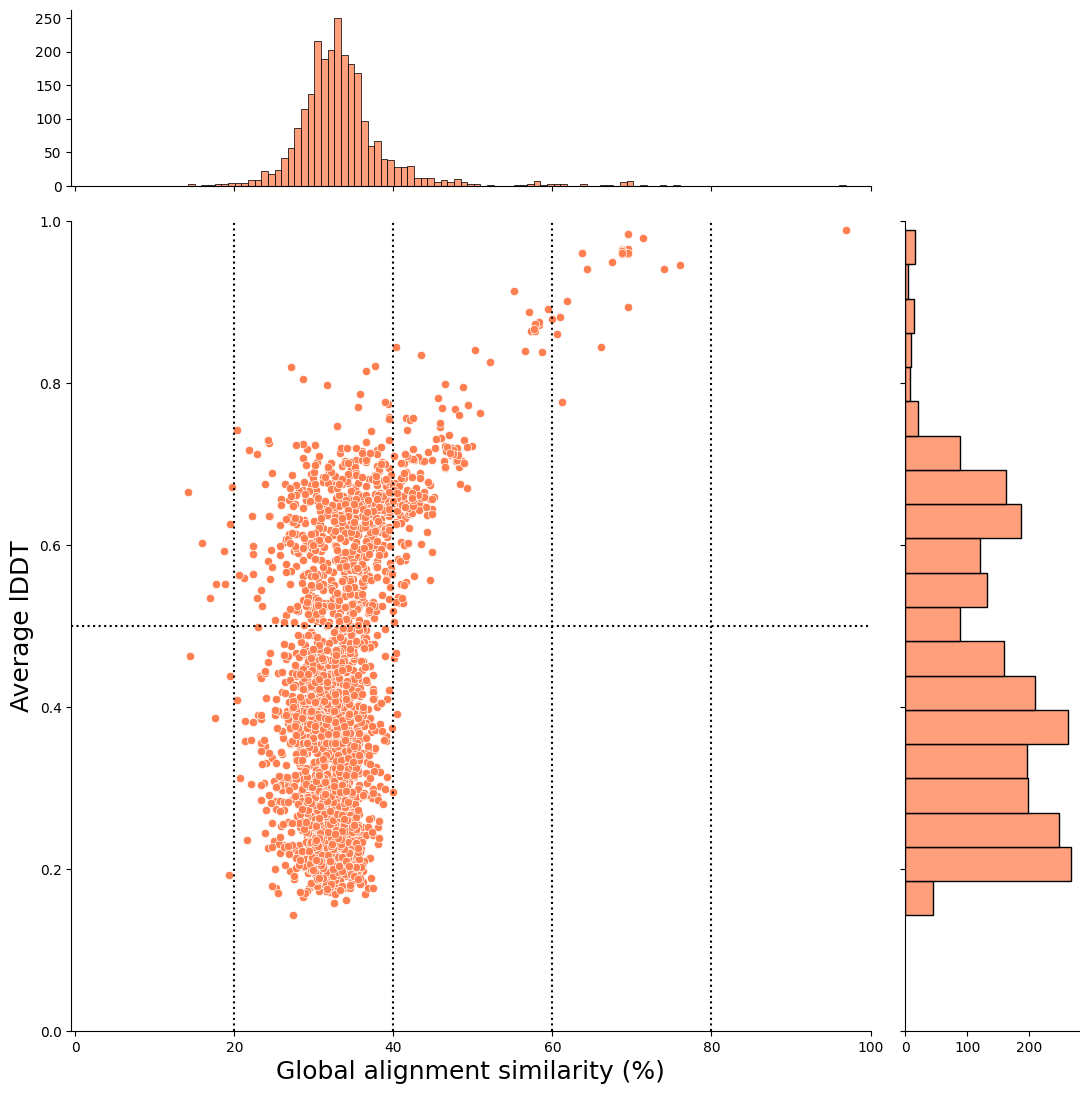

In [19]:
foldseek_filter_viz_pd = foldseek_filter_viz.to_pandas()

plt.figure(figsize=(8, 8), dpi=500)

sns.jointplot(
    data=foldseek_filter_viz_pd,
    x="Similarity_percent_needle",
    y="lddt",
    color="coral",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(-0.5,100)
plt.ylim(0,1)
plt.xlabel("Global alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_needle_lddt_filter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 4000x4000 with 0 Axes>

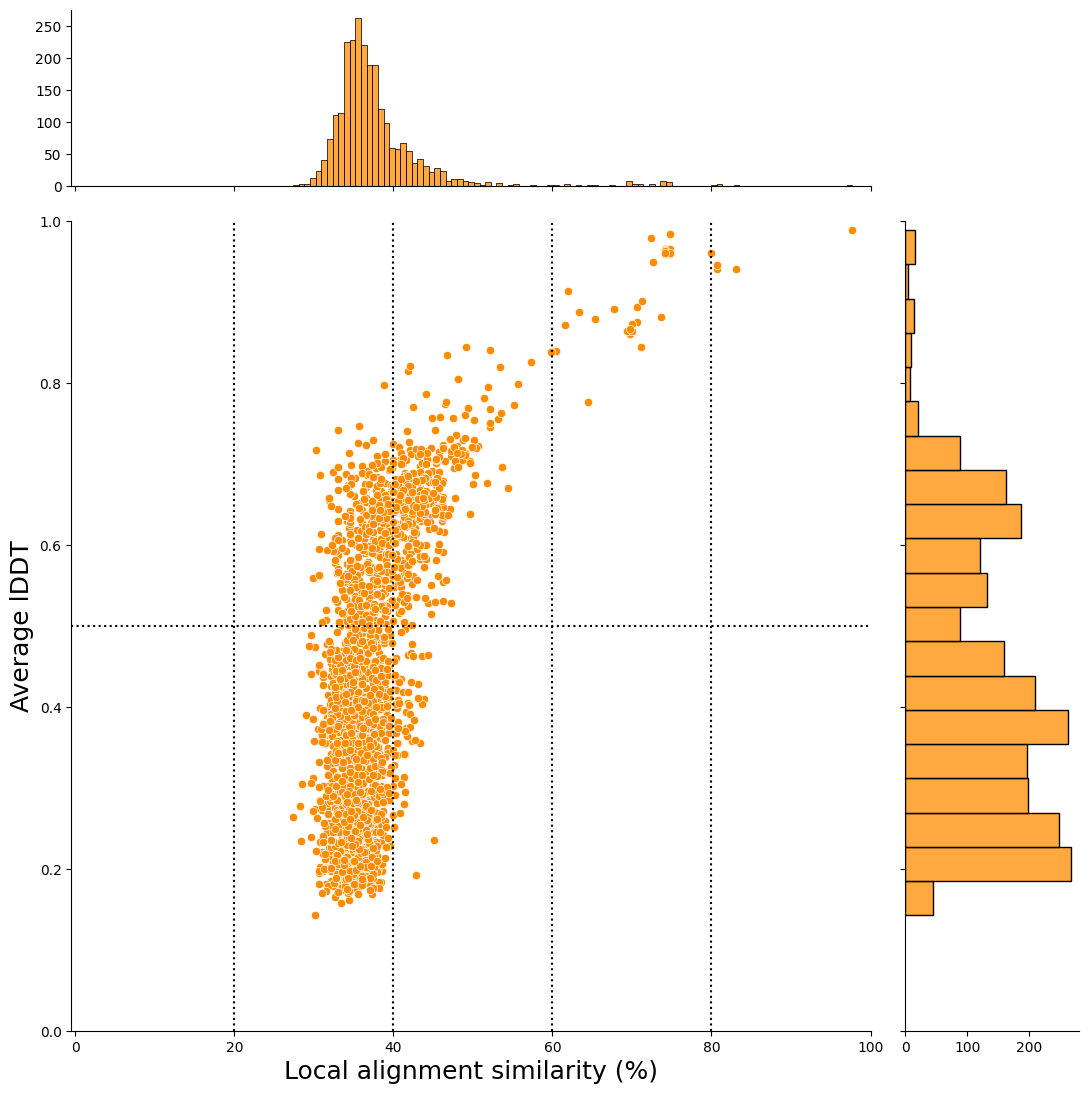

In [20]:
foldseek_filter_viz_pd = foldseek_filter_viz.to_pandas()

plt.figure(figsize=(8, 8), dpi=500)

sns.jointplot(
    data=foldseek_filter_viz_pd,
    x="Similarity_percent_water",
    y="lddt",
    color="darkorange",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(-0.5,100)
plt.ylim(0,1)
plt.xlabel("Local alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_water_lddt_filter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;
